In [1]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best)

from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 ECFP_counts,
                                 MACCS_keys,
                                 PathFP,
                                 UnscaledPhyschemDescriptors,
                                 UnscaledJazzyDescriptors,
                                 CompositeDescriptor,
                                 Avalon,
                                 PhyschemDescriptors,
                                 JazzyDescriptors)
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef, average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import auc as AUC

sns.set_theme(style="white", palette='bright')

In [2]:
config = OptimizationConfig(
    
    data = Dataset(
        input_column = 'Structure',
        response_column = 'Class',
        training_dataset_file=r'M:\ML_scripts\in-domain\CM\AD-CM-60_training_set.csv',
        test_dataset_file=r'M:\ML_scripts\in-domain\CM\AD-CM-60_testing_set.csv',
    ),
    descriptors=[

        CompositeDescriptor.new(
            descriptors=[
                ECFP.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        )
    ],
    algorithms=[
        RandomForestClassifier.new(),

    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        n_trials=200,
        n_startup_trials=50,
        direction=OptimizationDirection.MAXIMIZATION,
        random_seed=42,
        n_jobs=-1
    ),
)

# Run the optimization

study = optimize(config, study_name='study')

build_best(buildconfig_best(study), "./AD-CM-60.pkl")

with open("./AD-CM-60.pkl", "rb") as f:
    model = pickle.load(f)

[I 2025-07-07 13:56:15,045] A new study created in memory with name: study
[I 2025-07-07 13:56:15,124] A new study created in memory with name: study_name_0
[I 2025-07-07 13:56:25,577] Trial 0 finished with value: 0.7637181294830495 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 13, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 239, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsParti

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 32, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 241, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-07-07 14:01:09,301] Trial 64 finished with value: 0.7635406569711363 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 237, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO",

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 23, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 224, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-07-07 14:03:58,769] Trial 87 finished with value: 0.7637244104893838 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 22, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 231, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO",

...

[I 2025-07-07 14:15:06,899] Trial 192 finished with value: 0.763612929725074 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 22, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 233, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO",

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 23, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 237, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-07-07 14:15:24,136] Trial 196 finished with value: 0.7636397131869337 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 24, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 239, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO"

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 21, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 232, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-07-07 14:15:30,240] Trial 199 finished with value: 0.7614382181919682 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 8, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 226, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO",

In [3]:
best_trial = model.metadata['buildconfig']['metadata']['best_trial']
trials_df = study.trials_dataframe()

row = trials_df.loc[best_trial, 'user_attrs_test_scores']
keys = ['roc_auc','mcc','auc_pr_cal']
filtered_dict = {key: row[key] for key in keys if key in row}

new_df = pd.DataFrame(filtered_dict)
new_df['model'] = 'tm60_RF'

cols = ['model'] + [col for col in new_df.columns if col != 'model']
new_df = new_df[cols]

trials_df.to_csv('./ad-cm60_trials.csv')
new_df.to_csv('./ad-cm60-best_trial_fold_metrics.csv')

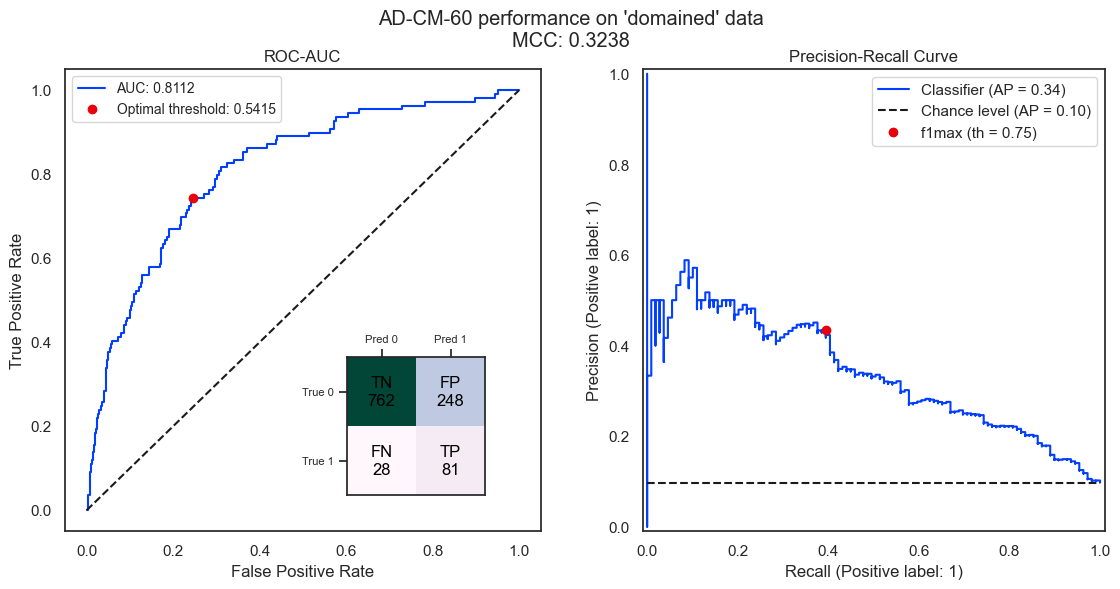

In [4]:
fig, axs = plt.subplots(1,2, figsize=(13.5, 6))                                     
x = np.linspace(0,1)

test_data = pd.read_csv(config.data.test_dataset_file)                         
test_smiles = test_data[config.data.input_column]                            
y_true = test_data[config.data.response_column]                                 

y_pred = model.predict_from_smiles(test_smiles)                                 

plt.subplot(121)
## Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred)           
auc = np.trapz(tpr, fpr) 
                                          
plt.plot(fpr, tpr)                                               
axs[0].set_title('ROC-AUC')

## Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

## Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"AD-CM-60 performance on 'domained' data\nMCC: {mcc:.4}")           
                         

cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()